# 03. 검증 설계

**이 노트북이 보고서에서 승부가 갈리는 지점이다.**

사기 수법은 시간에 따라 변한다. 랜덤 split은 여러 기간과 반복 개체를
학습·평가 양쪽에 섞어 성능을 낙관적으로 만들 수 있다. 여기서 이를 **실증**하고,
이후 모든 노트북이 쓸 시간 기반 split을 확정한다.

```
시간축 ────────────────────────────────────────────►
[      train      ][  calib  ][   test (정책 평가)   ]
```

In [19]:
import sys
from pathlib import Path

# src/ 를 import 경로에 추가 (uv pip install -e . 를 했다면 불필요)
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 운영체제별 폰트 설정 (예: 윈도우 맑은 고딕, 맥 애플고딕)
import matplotlib.font_manager as fm
import platform

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 110

if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    # Colab의 경우 나눔고딕 설치 후 적용 필요
    plt.rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

from frauddetectionreport import config, data, splits
from frauddetectionreport.config import TARGET, TIME_COL, AMOUNT_COL

train = data.load("train")
y = train[TARGET].to_numpy()
print(train.shape)

(590540, 434)


## 1. 분할 정의

시각 기준으로 자른다. 건수 기준이 아닌 이유: 거래량이 기간마다 다르므로
시각 기준이라야 '이 시점 이후는 미래'라는 의미가 정확해진다.

In [20]:
sp = splits.make_time_split(train)
display(sp.summary(train))

print(f"\n경계: train ≤ {sp.cut_train:,.0f} < calib ≤ {sp.cut_calib:,.0f} < test")

,split,n,days,fraud_rate
0,train,383851,110.280521,0.034196
1,calib,88581,29.839352,0.039207
2,test,118108,41.877674,0.034409



경계: train ≤ 9,614,667 < calib ≤ 12,192,854 < test


Task was destroyed but it is pending!
task: <Task pending name='Task-310' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\fraudDetectionReport\.venv\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-311' coro=<Kernel.shell_main() running at C:\fraudDetectionReport\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\fraudDetectionReport\.venv\Lib\site-packages\zmq\eventloop\zmqstream.py:564]>
C:\fraudDetectionReport\.venv\Lib\site-packages\matplotlib\transforms.py:193: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  ref = weakref.ref(
Task was destroyed but it is pending!
task: <Task pending name='Task-311' coro=<Kernel.shell_main() running at C:\fraudDetectionReport\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>
Task was destroyed but it is pending!
task: <Task pending name='Task-339' coro=<_async_in_context.<l

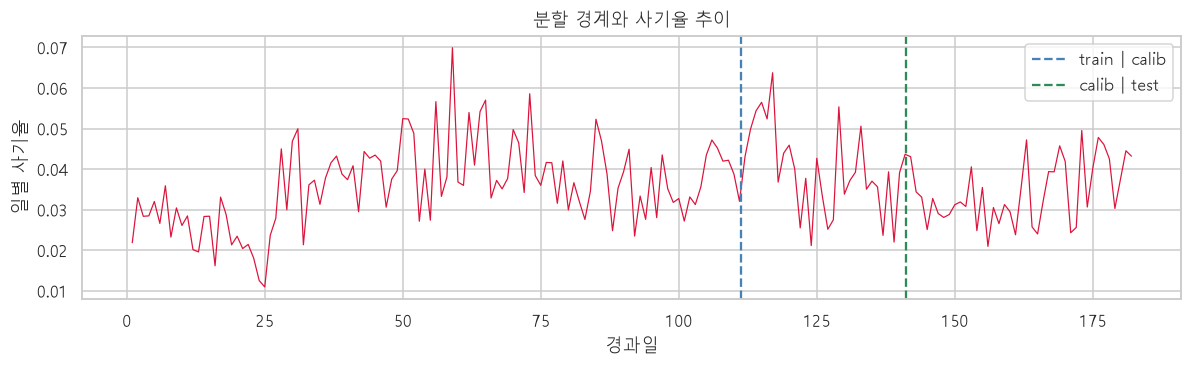

In [21]:
day = (train[TIME_COL] // 86400).astype(int)
daily = train.groupby(day).agg(n=(TARGET, "size"), fr=(TARGET, "mean"))

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(daily.index, daily["fr"], lw=0.8, color="crimson")
for cut, name, c in [(sp.cut_train, "train│calib", "steelblue"),
                     (sp.cut_calib, "calib│test", "seagreen")]:
    ax.axvline(cut / 86400, ls="--", c=c, lw=1.5, label=name)
ax.set_xlabel("경과일"); ax.set_ylabel("일별 사기율"); ax.legend()
ax.set_title("분할 경계와 사기율 추이")
plt.tight_layout(); plt.show()

## 2. 드리프트 확인

구간 간 사기율과 주요 변수 분포가 얼마나 다른가.
차이가 크다면 **모델이 학습한 패턴이 test에서 유효하지 않을 수 있다**는
경고이고, 06의 기간별(test 전반/후반) 안정성 점검이 그만큼 중요해진다.

In [22]:
rows = []
for name, m in [("train", sp.train), ("calib", sp.calib), ("test", sp.test)]:
    sub = train.loc[m]
    rows.append({
        "split": name, "n": len(sub),
        "fraud_rate": sub[TARGET].mean(),
        "amt_median": sub[AMOUNT_COL].median(),
        "amt_mean": sub[AMOUNT_COL].mean(),
        "fraud_amt_share": sub.loc[sub[TARGET] == 1, AMOUNT_COL].sum() / sub[AMOUNT_COL].sum(),
    })
display(pd.DataFrame(rows).style.format({
    "fraud_rate": "{:.4%}", "amt_median": "{:.1f}",
    "amt_mean": "{:.1f}", "fraud_amt_share": "{:.2%}"}))

,split,n,fraud_rate,amt_median,amt_mean,fraud_amt_share
0,train,383851,3.4196%,69.0,134.5,3.67%
1,calib,88581,3.9207%,67.9,134.2,4.89%
2,test,118108,3.4409%,68.5,137.5,3.75%


### 범주형 분포의 이동

train에 없던 범주가 test에 나타나는지 확인한다.
빈도 인코딩(04)을 할 때 미등장 범주 처리 방침이 필요하다.

In [23]:
for col in ["ProductCD", "DeviceType", "card4", "card6"]:
    if col not in train.columns:
        continue
    tr_cat = set(train.loc[sp.train, col].dropna().unique())
    te_cat = set(train.loc[sp.test, col].dropna().unique())
    new = te_cat - tr_cat
    print(f"{col:12s} train {len(tr_cat):4d}종  test 신규 {len(new):3d}종  {list(new)[:5]}")

ProductCD    train    5종  test 신규   0종  []
DeviceType   train    2종  test 신규   0종  []
card4        train    4종  test 신규   0종  []
card6        train    4종  test 신규   0종  []


## 3. 랜덤 split의 낙관 편향 — 실증

**같은 모델, 같은 피처로 두 가지 split만 바꿔 학습**하고 성능을 비교한다.
랜덤 split이 더 좋게 나온다면 시간 순서를 무시한 평가가 만드는 **낙관 편향**을 보여준다.
다만 이 차이에는 반복 개체 효과와 기간 분포 차이가 함께 포함되므로 순수 누수량으로 해석하지 않는다.

여기서는 원시 수치형 변수만으로 빠르게 확인한다
(정교한 피처는 04에서 만든다).

In [24]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, average_precision_score

num_cols = [c for c in train.columns
            if train[c].dtype.kind in "fiu" and c not in (TARGET, "TransactionID")]
X = train[num_cols]

LGB_PARAMS = dict(objective="binary", learning_rate=0.05, num_leaves=63,
                  min_child_samples=100, feature_fraction=0.7, bagging_fraction=0.8,
                  bagging_freq=1, verbose=-1, seed=config.RANDOM_SEED, n_jobs=-1)

def quick_fit(tr_mask, va_mask, n_rounds=300):
    ds_tr = lgb.Dataset(X[tr_mask], y[tr_mask])
    # 평가 구간 라벨로 반복 수를 고르지 않는다. 두 split 모두 같은 고정 반복 수를 쓴다.
    m = lgb.train(LGB_PARAMS, ds_tr, num_boost_round=n_rounds)
    pr = m.predict(X[va_mask])
    return {"roc_auc": roc_auc_score(y[va_mask], pr),
            "pr_auc": average_precision_score(y[va_mask], pr),
            "n_rounds": n_rounds}

In [25]:
%%time
# (a) 시간 기반: train 구간으로 학습, test 구간으로 평가
time_res = quick_fit(sp.train, sp.test)

# (b) 랜덤: 학습·평가 건수를 시간 기반과 동일하게 맞춘 비교용 분할
rng = np.random.default_rng(config.RANDOM_SEED)
perm = rng.permutation(len(train))
rnd_tr = np.zeros(len(train), dtype=bool)
rnd_va = np.zeros(len(train), dtype=bool)
rnd_tr[perm[:sp.train.sum()]] = True
rnd_va[perm[sp.train.sum():sp.train.sum() + sp.test.sum()]] = True
rand_res = quick_fit(rnd_tr, rnd_va)

cmp = pd.DataFrame([{"split": "시간 기반", **time_res},
                    {"split": "랜덤", **rand_res}]).set_index("split")
cmp.loc["차이 (랜덤 − 시간)"] = cmp.loc["랜덤"] - cmp.loc["시간 기반"]
display(cmp.style.format("{:.4f}"))

,roc_auc,pr_auc,n_rounds
split,,,
시간 기반,0.8884,0.4972,300.0000
랜덤,0.9402,0.7289,300.0000
차이 (랜덤 − 시간),0.0518,0.2317,0.0000


CPU times: total: 13min 20s
Wall time: 3min 18s


> 랜덤 split의 성능이 더 높다면 시간 순서를 무시한 평가가 낙관적이라는 증거다.
> 같은 카드·계정의 반복 거래가 양쪽에 섞이는 효과와 기간별 분포 차이가 함께
> 작용하므로, 수치 차이를 순수한 누수량으로 단정하지 않는다.
>
> 보고서 §3에 이 표를 그대로 싣는다.

## 4. train 내부 시간 CV

하이퍼파라미터 탐색은 train 구간 **안에서만** 한다.
calib과 test는 건드리지 않는다.

In [26]:
folds = splits.time_series_folds(train, sp.train, n_folds=4)
for i, (f_tr, f_va) in enumerate(folds):
    print(f"fold {i}: train {f_tr.sum():7,d}건  valid {f_va.sum():7,d}건  "
          f"(사기율 {y[f_va].mean():.4f})")

fold 0: train  76,771건  valid  76,770건  (사기율 0.0265)
fold 1: train 153,541건  valid  76,770건  (사기율 0.0414)
fold 2: train 230,311건  valid  76,771건  (사기율 0.0407)
fold 3: train 307,082건  valid  76,769건  (사기율 0.0355)


## 5. test 재분할 — 정책 선택 과적합 방지

여러 정책을 test에서 비교해 최고를 고르면 test에 과적합된다.
우리는 '정책을 고르는 것'이 목적이므로 이 위험이 실재한다.

test를 전반/후반으로 나눠 **앞에서 선택, 뒤에서 확인**한다.
드리프트 하에서 정책이 유지되는지도 함께 볼 수 있다.

In [27]:
test_a, test_b = splits.split_test_halves(train, sp.test)
for name, m in [("test 전반 (선택용)", test_a), ("test 후반 (확인용)", test_b)]:
    sub = train.loc[m]
    print(f"{name:20s} {len(sub):7,d}건  사기율 {sub[TARGET].mean():.4%}  "
          f"{(sub[TIME_COL].max()-sub[TIME_COL].min())/86400:.0f}일")

test 전반 (선택용)         59,054건  사기율 3.1344%  21일
test 후반 (확인용)         59,054건  사기율 3.7474%  21일


## 요약

- 시간 기반 3분할 확정 → `splits.make_time_split()` 으로 고정, 이후 노트북이 재사용
- 랜덤 split의 낙관 편향 실증 → 보고서 §3의 근거
- train 내부 시간 CV 폴드 정의
- test 전/후반 분리 → 정책 선택 과적합 방지

다음: `04_features` — 피처 엔지니어링